In [2]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, MaxPooling2D, Dropout
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import pytesseract
import os
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression


In [3]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
x_train = x_train.reshape((-1, 28, 28, 1))
x_test = x_test.reshape((-1, 28, 28, 1))

num_classes = 15
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)


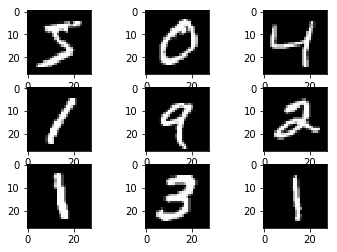

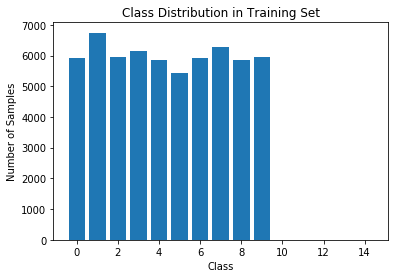

In [4]:
# Display some sample images
for i in range(9):
    plt.subplot(330 + 1 + i)
    plt.imshow(x_train[i].reshape(28, 28), cmap=plt.get_cmap('gray'))
plt.show()

# Analyze dataset distribution
class_distribution = np.sum(y_train, axis=0)
plt.bar(range(num_classes), class_distribution)
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.title('Class Distribution in Training Set')
plt.show()


In [5]:
model = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])


In [6]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])


In [7]:
history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=14, batch_size=128)
cnn_accuracy = history.history['val_accuracy'][-1]
print(f"CNN Validation Accuracy: {cnn_accuracy}")


Epoch 1/14
469/469 [==============================] - 15s 31ms/step - loss: 0.9601 - accuracy: 0.7103 - val_loss: 0.2455 - val_accuracy: 0.9313
Epoch 2/14
469/469 [==============================] - 15s 31ms/step - loss: 0.2975 - accuracy: 0.9133 - val_loss: 0.1479 - val_accuracy: 0.9559
Epoch 3/14
469/469 [==============================] - 15s 32ms/step - loss: 0.2085 - accuracy: 0.9394 - val_loss: 0.1118 - val_accuracy: 0.9650
Epoch 4/14
469/469 [==============================] - 16s 34ms/step - loss: 0.1676 - accuracy: 0.9509 - val_loss: 0.0923 - val_accuracy: 0.9711
Epoch 5/14
469/469 [==============================] - 16s 33ms/step - loss: 0.1444 - accuracy: 0.9572 - val_loss: 0.0791 - val_accuracy: 0.9733
Epoch 6/14
469/469 [==============================] - 15s 33ms/step - loss: 0.1244 - accuracy: 0.9636 - val_loss: 0.0669 - val_accuracy: 0.9784
Epoch 7/14
469/469 [==============================] - 15s 33ms/step - loss: 0.1112 - accuracy: 0.9668 - val_loss: 0.0631 - val_accuracy:

313/313 [==============================] - 1s 4ms/step


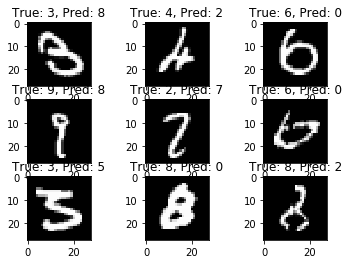

In [8]:
#example on missclassified images
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)
misclassified_indices = np.where(y_pred_classes != y_true)[0]

#show some of missclassified images
for i, mis_idx in enumerate(misclassified_indices[:9]):
    plt.subplot(330 + 1 + i)
    plt.imshow(x_test[mis_idx].reshape(28, 28), cmap=plt.get_cmap('gray'))
    plt.title(f"True: {y_true[mis_idx]}, Pred: {y_pred_classes[mis_idx]}")
plt.show()


In [9]:
#flatten the images for SVM
x_train_flat = x_train.reshape(-1, 28*28)
x_test_flat = x_test.reshape(-1, 28*28)

#train svm
svm_model = SVC(gamma='scale')
svm_model.fit(x_train_flat, np.argmax(y_train, axis=1))

#predict and evaluate the SVM model
svm_predictions = svm_model.predict(x_test_flat)
svm_accuracy = accuracy_score(np.argmax(y_test, axis=1), svm_predictions)
print(f"SVM Accuracy: {svm_accuracy}")

#initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(max_iter=1000)
log_reg_model.fit(x_train_flat, np.argmax(y_train, axis=1))

#predict and evaluate the Logistic Regression model
log_reg_predictions = log_reg_model.predict(x_test_flat)
log_reg_accuracy = accuracy_score(np.argmax(y_test, axis=1), log_reg_predictions)
print(f"Logistic Regression Accuracy: {log_reg_accuracy}")


SVM Accuracy: 0.9792
Logistic Regression Accuracy: 0.9256


313/313 [==============================] - 1s 4ms/step
Model Performance Comparison:
CNN Accuracy: 0.9863
SVM Accuracy: 0.9792
Logistic Regression Accuracy: 0.9256


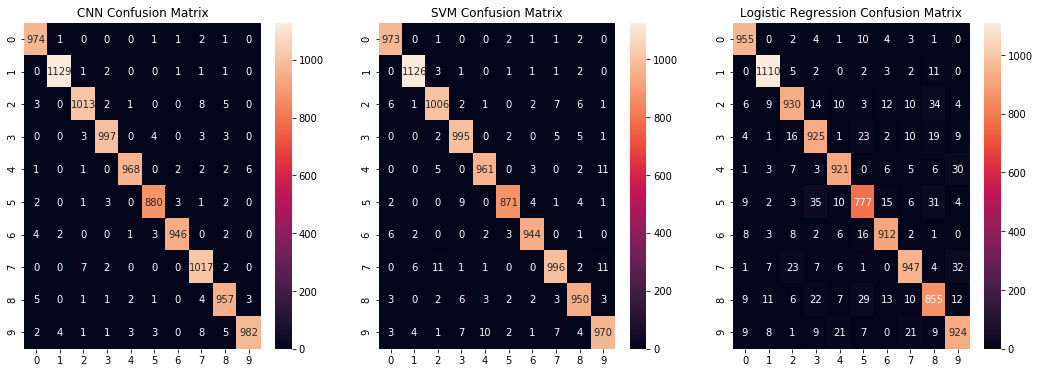


CNN Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.98      0.98      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.97      0.99      0.98      1028
           8       0.98      0.98      0.98       974
           9       0.99      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000


SVM Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def compare_model_results(cnn_model, svm_model, log_reg_model, x_test, y_test):
    # Predictions from each model
    cnn_predictions = np.argmax(cnn_model.predict(x_test), axis=1)
    svm_predictions = svm_model.predict(x_test.reshape(-1, 28*28))
    log_reg_predictions = log_reg_model.predict(x_test.reshape(-1, 28*28))

    # True labels
    y_true = np.argmax(y_test, axis=1)

    # Compute accuracy for each model
    cnn_accuracy = accuracy_score(y_true, cnn_predictions)
    svm_accuracy = accuracy_score(y_true, svm_predictions)
    log_reg_accuracy = accuracy_score(y_true, log_reg_predictions)

    print("Model Performance Comparison:")
    print(f"CNN Accuracy: {cnn_accuracy}")
    print(f"SVM Accuracy: {svm_accuracy}")
    print(f"Logistic Regression Accuracy: {log_reg_accuracy}")

    # Plotting Confusion Matrices
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    sns.heatmap(confusion_matrix(y_true, cnn_predictions), annot=True, fmt="d", ax=axes[0])
    axes[0].set_title('CNN Confusion Matrix')
    sns.heatmap(confusion_matrix(y_true, svm_predictions), annot=True, fmt="d", ax=axes[1])
    axes[1].set_title('SVM Confusion Matrix')
    sns.heatmap(confusion_matrix(y_true, log_reg_predictions), annot=True, fmt="d", ax=axes[2])
    axes[2].set_title('Logistic Regression Confusion Matrix')
    plt.show()

    # Printing Classification Reports
    print("\nCNN Classification Report:\n", classification_report(y_true, cnn_predictions))
    print("\nSVM Classification Report:\n", classification_report(y_true, svm_predictions))
    print("\nLogistic Regression Classification Report:\n", classification_report(y_true, log_reg_predictions))

# Call the function with the models and test data
compare_model_results(model, svm_model, log_reg_model, x_test, y_test)


In [35]:
def invert_colors(image):
    # Invert the colors by subtracting each pixel value from 255
    inverted_image = cv2.bitwise_not(image)
    return inverted_image

def classify_element(element_text):
    if element_text == '+':
        return 'addition'
    elif element_text == '-':
        return 'subtraction'
    elif element_text == '*':
        return 'multiplication'
    elif element_text == '/':
        return 'division'
    else:
        return 'digit'

def resize_image(image, target_size=(28, 28)):
    # Resize the image to the target size
    resized_image = cv2.resize(image, target_size, interpolation=cv2.INTER_AREA)
    return resized_image

def extract_operations_from_image(image_path, output_folder):
    # Read the input image
    image = cv2.imread(image_path)

    # Convert the image to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Apply thresholding to get a binary image
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Find contours in the binary image
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Sort contours based on x-coordinate
    contours = sorted(contours, key=lambda x: cv2.boundingRect(x)[0])

    # List to store detected operations
    detected_operations = []

    # Output folder to save cut images
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    # Loop through the sorted contours to extract individual digits and operations
    for i, contour in enumerate(contours):
        # Get bounding box for each contour
        x, y, w, h = cv2.boundingRect(contour)

        # Filter out small contours (adjust the threshold as needed)
        if w * h < 100:
            continue

        # Extract the region of interest (ROI) from the original image
        element_roi = image[y-8:y + h+8, x-8:x + w+8]

        # Invert the colors of the element_roi
        inverted_roi = invert_colors(element_roi)

        # Resize the inverted image to 28x28
        resized_roi = resize_image(inverted_roi, target_size=(28, 28))

        # Save the resized image with a name like "element_1_digit.jpg"
        element_name = f"element_{i + 1}_{classify_element(pytesseract.image_to_string(inverted_roi))}.jpg"
        cv2.imwrite(os.path.join(output_folder, element_name), resized_roi)

        # Perform OCR on the element using pytesseract
        element_text = pytesseract.image_to_string(inverted_roi,
                                                    config='--psm 10 --oem 3 -c tessedit_char_whitelist=0123456789+-*/')

        # Classify the element
        element_type = classify_element(element_text.strip())

        # If the element is an operation, add it to the detected_operations list
        if element_type != 'digit':
            detected_operations.append(element_type)

    # Create a summary of detected operations
    return detected_operations

# Function to predict digit from input image array
def predict_digit(model, img_array):
    prediction = model.predict(img_array)
    predicted_digit = np.argmax(prediction)
    return predicted_digit

# Function to preprocess the input image for digit prediction
def preprocess_input_image(image_path):
    img = Image.open(image_path).convert('L')  # Convert to grayscale
    img = img.resize((28, 28))                 # Resize the image to 28x28
    img_array = np.array(img).astype('float32') / 255.0  # Normalize to [0, 1]
    img_array = img_array.reshape((1, 28, 28, 1))
    return img_array


In [ ]:
if __name__ == "__main__":
    # Get the input image path from the user
    image_path = r"Pictures\1.png"

    # Specify the output folder for saving cut images
    output_folder = r"Pictures\out"

    # Extract operations from the image and save cut images
    operations = extract_operations_from_image(image_path, output_folder)

    # Use the operations variable as needed
    print("Detected Operations:", operations)




def predict_digit(model, img_array):
    prediction = model.predict(img_array)
    predicted_digit = np.argmax(prediction)
    return predicted_digit

num_images = 3



# Predict digits from input images
predicted_digits = []
for i in range(1, num_images * 2 + 1, 2):
    # Formulate the image filename based on the pattern (e.g., element_1_digit, element_3_digit, ...)
     filename = rf"{output_folder}\element_{i}_digit.jpg"
    
    # Load and preprocess the input image
     img_array = preprocess_input_image(filename)
    
    # Call the predict_digit function for each image and store the result
     predicted_digits.append(predict_digit(model, img_array))

# Print the array of predicted digits
print("Predicted digits for all images:", predicted_digits)
b=extract_operations_from_image(image_path, output_folder)
a=predicted_digits

# Perform multiplication and division first
i = 0
while i < len(b):
    if b[i] == "multiplication":
        a[i] = a[i] * a[i + 1]
        del a[i + 1]
        del b[i]
    elif b[i] == "division":
        a[i] = a[i] / a[i + 1]
        del a[i + 1]
        del b[i]
    else:
        i += 1

# Now, perform addition and subtraction
result = a[0]
for i in range(len(b)):
    if b[i] == "addition":
        result += a[i + 1]
    elif b[i] == "subtraction":
        result -= a[i + 1]

print(result)

Detected Operations: ['multiplication', 'addition']
1/1 [==============================] - 0s 19ms/step
Predicted digits for all images: [3, 5, 1]
16
